---
# TaMtD Pre-testing
---

In [10]:
import importlib

import jpeg_entropy_reader
import jpeg_coefficient_decoder
import train_jpeg_decoder

importlib.reload(jpeg_entropy_reader)
importlib.reload(jpeg_coefficient_decoder)
importlib.reload(train_jpeg_decoder)

from jpeg_entropy_reader import JPEGEntropyReader
from jpeg_coefficient_decoder import JPEGCoefficientDecoderModel
from train_jpeg_decoder import psnr, reconstruction_loss

from datasets import load_dataset
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [11]:
PROJECT_DIR = Path("TaMtD/Decoder Models/JPEG Pretest")

if not PROJECT_DIR.exists():
    PROJECT_DIR = Path(".")  # use this if the notebook is already in the JPEG Decoder Model folder

sys.path.insert(0, str(PROJECT_DIR.resolve()))

from jpeg_reader import JPEGReader
from jpeg_decoder import JPEGDecoderModel
from train_jpeg_decoder import HuggingFaceJPEGDataset, psnr, reconstruction_loss

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu" 
device

'mps'

In [12]:
class HFCoefficientJPEGDataset(Dataset):
    def __init__(self, dataset_name, split, image_size=64, quality=75, limit=None, image_column=None):
        self.dataset = load_dataset(dataset_name, split=split)
        if limit:
            self.dataset = self.dataset.select(range(min(limit, len(self.dataset))))

        self.image_column = image_column
        if self.image_column is None:
            for name in ("image", "img"):
                if name in self.dataset.column_names:
                    self.image_column = name
                    break
        if self.image_column is None:
            self.image_column = self.dataset.column_names[0]

        self.reader = JPEGEntropyReader(image_size=image_size, quality=quality)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index][self.image_column]
        if not isinstance(item, Image.Image):
            item = Image.open(item)

        sample = self.reader.encode_image(item)
        return sample.coefficients, sample.qtable, sample.target

In [ ]:
config = {
    "dataset": "uoft-cs/cifar10",
    "train_split": "train",
    "val_split": "test",
    "image_size": 32,
    "quality": 75,
    "dim": 192,
    "depth": 4,
    "heads": 6,
    "batch_size": 64,
    "epochs": 20,
    "lr": 3e-4,
    "weight_decay": 0.05,
    "workers": 0,
    "train_limit": 5000,
    "val_limit": 500,
    "output_dir": Path("runs/jpeg_coefficient_decoder_32px"),
}

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [30]:
train_dataset = HFCoefficientJPEGDataset(
    config["dataset"],
    config["train_split"],
    image_size=config["image_size"],
    quality=config["quality"],
    limit=config["train_limit"],
)

val_dataset = HFCoefficientJPEGDataset(
    config["dataset"],
    config["val_split"],
    image_size=config["image_size"],
    quality=config["quality"],
    limit=config["val_limit"],
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

len(train_dataset), len(val_dataset)

(5000, 500)

coefficients: torch.Size([16, 64]) -0.037109375 0.0341796875
qtable: torch.Size([64]) 0.019607843831181526 0.239215686917305
target: torch.Size([1, 32, 32]) 0.0941176488995552 0.8078431487083435


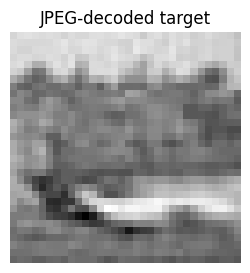

In [31]:
coefficients, qtable, target = train_dataset[0]

print("coefficients:", coefficients.shape, coefficients.min().item(), coefficients.max().item())
print("qtable:", qtable.shape, qtable.min().item(), qtable.max().item())
print("target:", target.shape, target.min().item(), target.max().item())

plt.figure(figsize=(3, 3))
plt.imshow(target.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("JPEG-decoded target")
plt.show()

In [32]:
model = JPEGCoefficientDecoderModel(
    image_size=config["image_size"],
    dim=config["dim"],
    depth=config["depth"],
    heads=config["heads"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

sum(p.numel() for p in model.parameters())

1906624

In [33]:
coefficients, qtable, target = next(iter(train_loader))
coefficients = coefficients.to(device)
qtable = qtable.to(device)
target = target.to(device)

with torch.no_grad():
    pred = model(coefficients, qtable)
    loss = reconstruction_loss(pred, target)

print("pred:", pred.shape, pred.min().item(), pred.max().item())
print("target:", target.shape)
print("initial loss:", loss.item())
print("initial PSNR:", psnr(pred, target).item())

pred: torch.Size([64, 1, 32, 32]) 0.3869316875934601 0.6376652121543884
target: torch.Size([64, 1, 32, 32])
initial loss: 0.3052689731121063
initial PSNR: 12.209861755371094


Epoch 1 val: 100%|██████████| 8/8 [00:00<00:00, 16.64it/s]


epoch=1 train_loss=0.2828 val_loss=0.2549 val_psnr=13.28


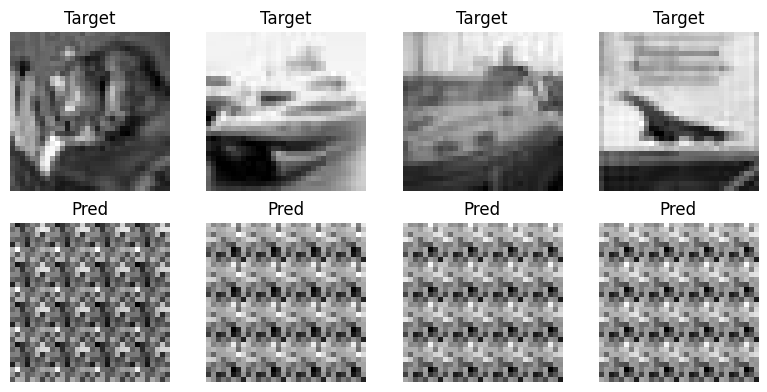

Epoch 2 val: 100%|██████████| 8/8 [00:00<00:00, 20.81it/s]


epoch=2 train_loss=0.2444 val_loss=0.2185 val_psnr=14.28


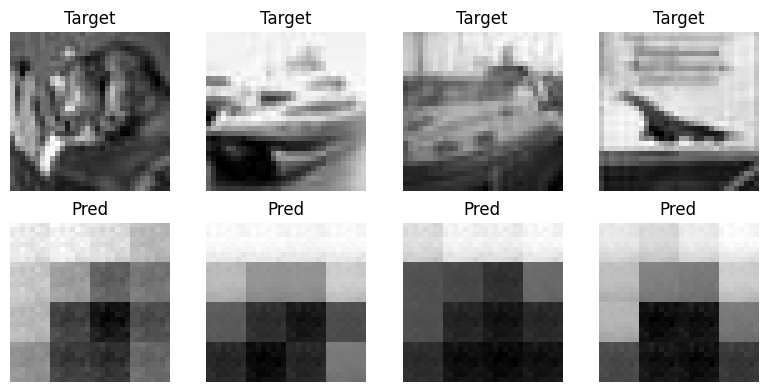

Epoch 3 val: 100%|██████████| 8/8 [00:00<00:00, 20.62it/s]


epoch=3 train_loss=0.1895 val_loss=0.1583 val_psnr=16.75


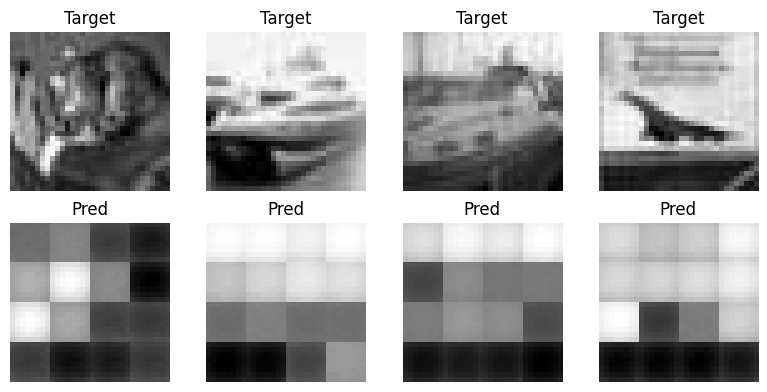

Epoch 4 val: 100%|██████████| 8/8 [00:00<00:00, 19.55it/s]


epoch=4 train_loss=0.1603 val_loss=0.1533 val_psnr=16.88


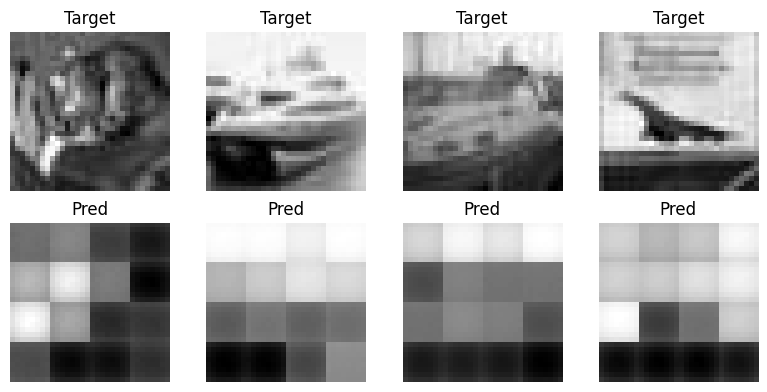

Epoch 5 val: 100%|██████████| 8/8 [00:00<00:00, 17.87it/s]


epoch=5 train_loss=0.1554 val_loss=0.1523 val_psnr=16.93


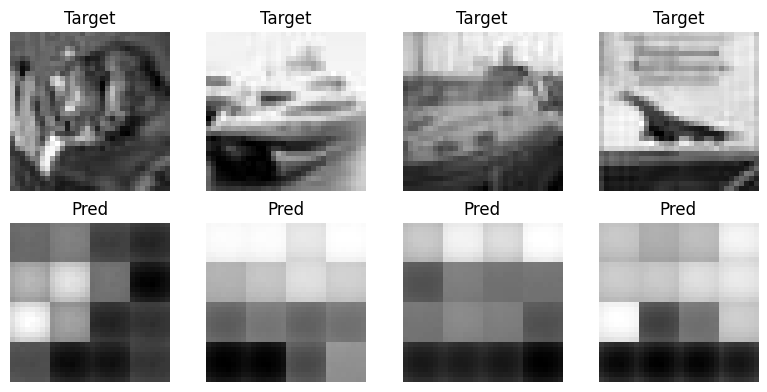

In [34]:
config["output_dir"].mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_psnr": []}

for epoch in range(1, config["epochs"] + 1):
    model.train()
    train_loss = 0.0

    for coefficients, qtable, target in tqdm(train_loader, desc=f"Epoch {epoch} train"):
        coefficients = coefficients.to(device)
        qtable = qtable.to(device)
        target = target.to(device)

        pred = model(coefficients, qtable)
        loss = reconstruction_loss(pred, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_psnr = 0.0
    preview_batch = None

    with torch.no_grad():
        for coefficients, qtable, target in tqdm(val_loader, desc=f"Epoch {epoch} val"):
            coefficients = coefficients.to(device)
            qtable = qtable.to(device)
            target = target.to(device)

            pred = model(coefficients, qtable)
            val_loss += reconstruction_loss(pred, target).item()
            val_psnr += psnr(pred, target).item()

            if preview_batch is None:
                preview_batch = (pred.cpu(), target.cpu())

    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)

    checkpoint = {
        "model": model.state_dict(),
        "config": config,
        "epoch": epoch,
        "val_loss": val_loss,
        "val_psnr": val_psnr,
    }

    torch.save(checkpoint, config["output_dir"] / "last.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, config["output_dir"] / "best.pt")

    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_psnr={val_psnr:.2f}"
    )

    pred_preview, target_preview = preview_batch

    plt.figure(figsize=(8, 4))
    for i in range(min(4, pred_preview.size(0))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(target_preview[i].squeeze(0), cmap="gray")
        plt.axis("off")
        plt.title("Target")

        plt.subplot(2, 4, i + 5)
        plt.imshow(pred_preview[i].clamp(0, 1).squeeze(0), cmap="gray")
        plt.axis("off")
        plt.title("Pred")

    plt.tight_layout()
    plt.show()

Epoch 36 val: 100%|██████████| 8/8 [00:00<00:00, 20.81it/s]


epoch=36 train_loss=0.0755 val_loss=0.0720 val_psnr=23.82


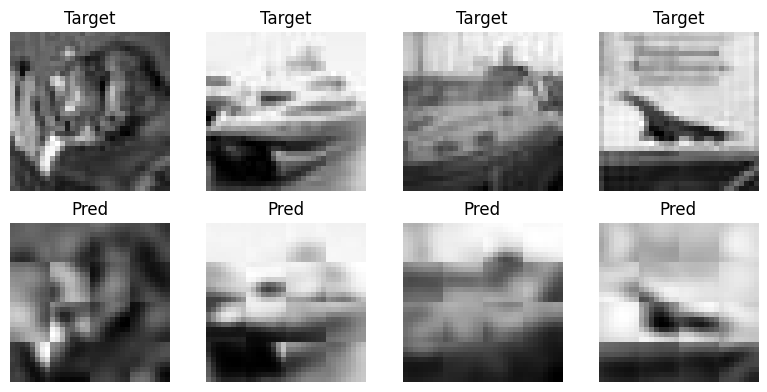

Epoch 37 val: 100%|██████████| 8/8 [00:00<00:00, 20.86it/s]


epoch=37 train_loss=0.0749 val_loss=0.0696 val_psnr=24.05


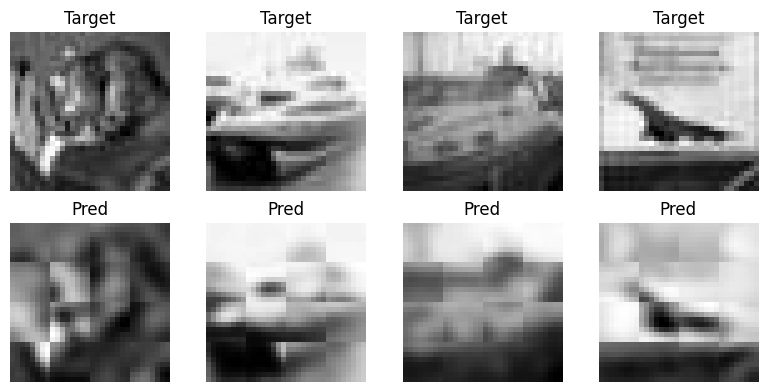

Epoch 38 val: 100%|██████████| 8/8 [00:00<00:00, 19.86it/s]


epoch=38 train_loss=0.0739 val_loss=0.0719 val_psnr=23.90


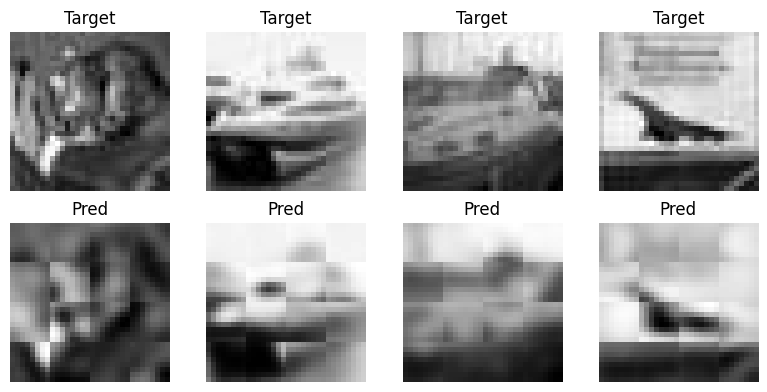

Epoch 39 val: 100%|██████████| 8/8 [00:00<00:00, 19.70it/s]


epoch=39 train_loss=0.0728 val_loss=0.0682 val_psnr=24.33


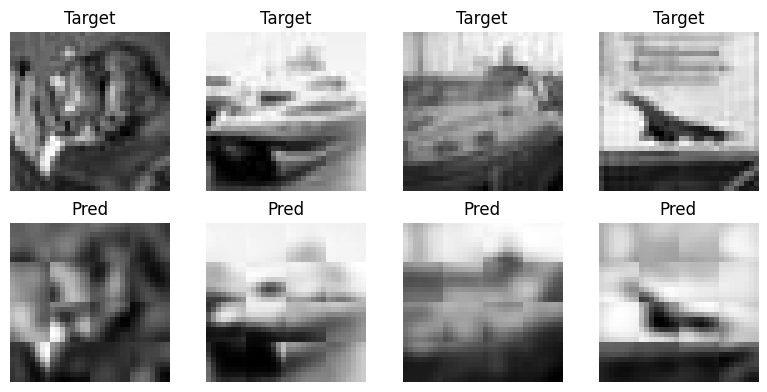

Epoch 40 val: 100%|██████████| 8/8 [00:00<00:00, 20.61it/s]


epoch=40 train_loss=0.0713 val_loss=0.0666 val_psnr=24.51


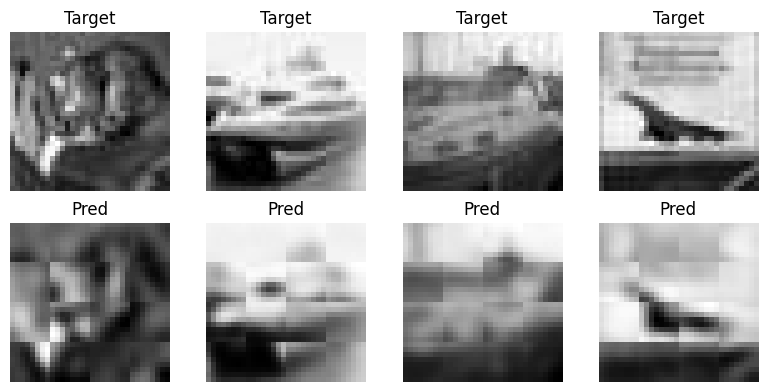

Epoch 41 val: 100%|██████████| 8/8 [00:00<00:00, 20.58it/s]


epoch=41 train_loss=0.0706 val_loss=0.0658 val_psnr=24.62


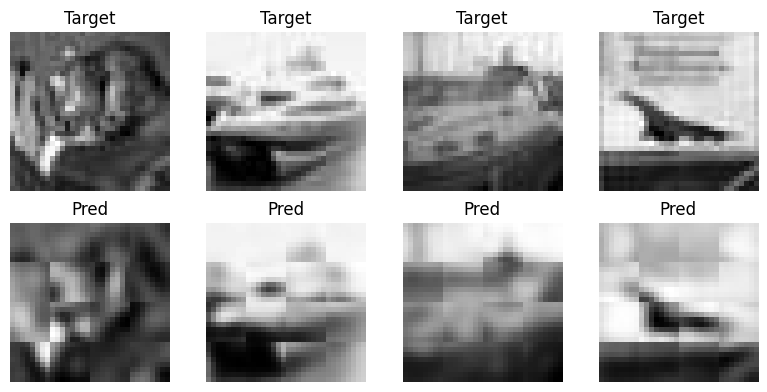

Epoch 42 val: 100%|██████████| 8/8 [00:00<00:00, 20.35it/s]


epoch=42 train_loss=0.0697 val_loss=0.0653 val_psnr=24.70


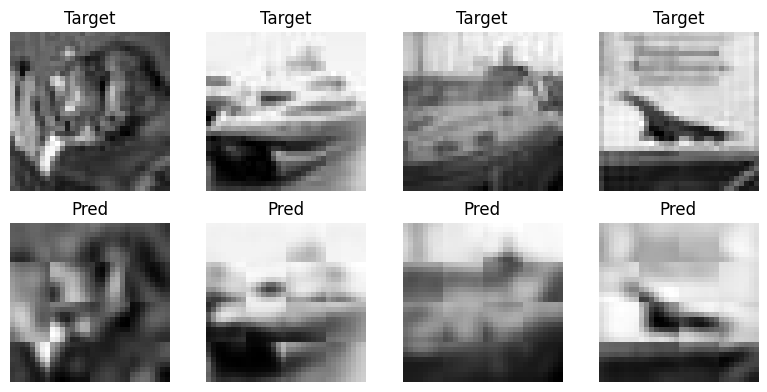

Epoch 43 val: 100%|██████████| 8/8 [00:00<00:00, 20.12it/s]


epoch=43 train_loss=0.0689 val_loss=0.0647 val_psnr=24.84


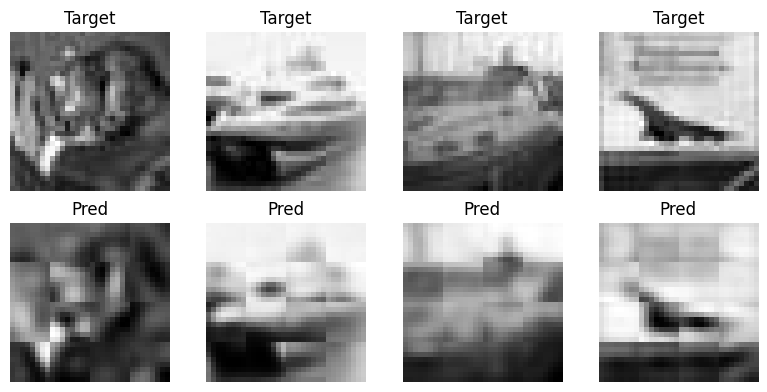

Epoch 44 val: 100%|██████████| 8/8 [00:00<00:00, 19.17it/s]


epoch=44 train_loss=0.0684 val_loss=0.0635 val_psnr=24.96


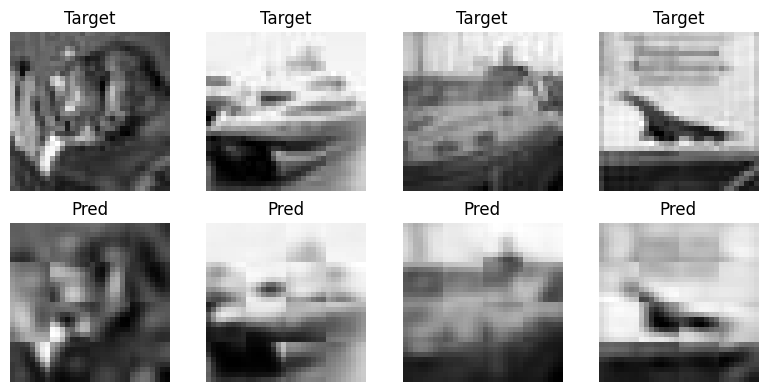

Epoch 45 val: 100%|██████████| 8/8 [00:00<00:00, 20.61it/s]


epoch=45 train_loss=0.0676 val_loss=0.0633 val_psnr=24.98


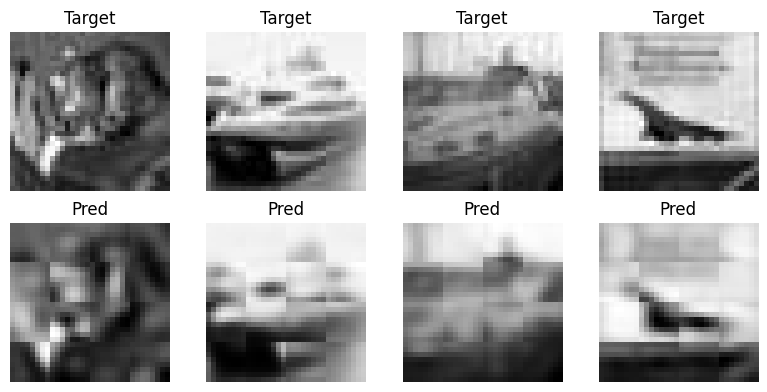

Epoch 46 val: 100%|██████████| 8/8 [00:00<00:00, 20.65it/s]


epoch=46 train_loss=0.0674 val_loss=0.0630 val_psnr=25.04


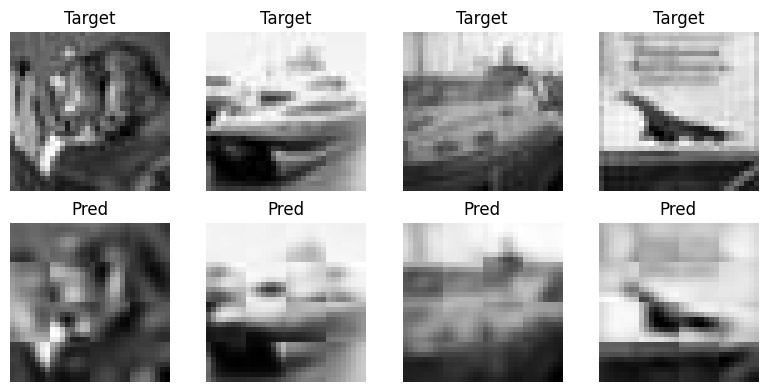

Epoch 47 val: 100%|██████████| 8/8 [00:00<00:00, 21.24it/s]


epoch=47 train_loss=0.0663 val_loss=0.0658 val_psnr=24.77


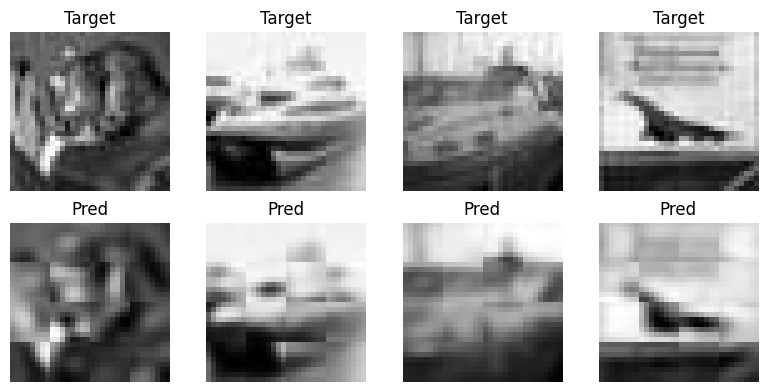

Epoch 48 val: 100%|██████████| 8/8 [00:00<00:00, 20.51it/s]


epoch=48 train_loss=0.0664 val_loss=0.0628 val_psnr=25.13


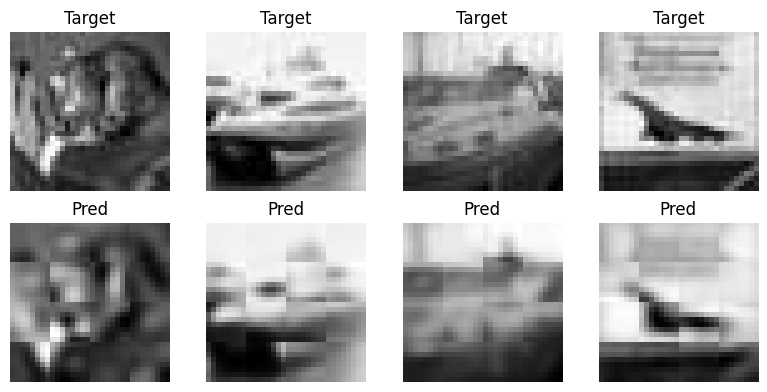

Epoch 49 val: 100%|██████████| 8/8 [00:00<00:00, 19.98it/s]


epoch=49 train_loss=0.0649 val_loss=0.0626 val_psnr=25.16


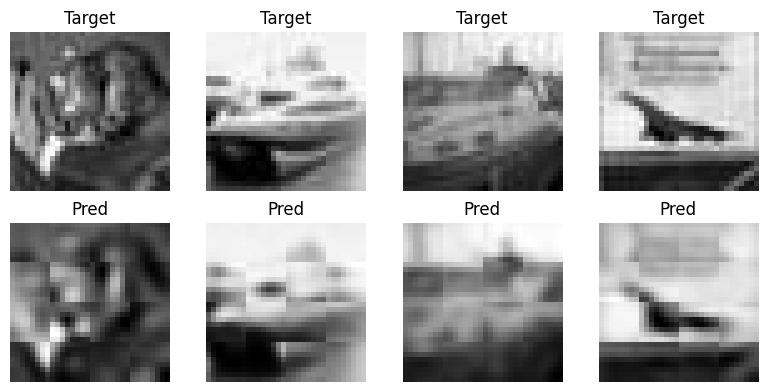

Epoch 50 val: 100%|██████████| 8/8 [00:00<00:00, 20.73it/s]


epoch=50 train_loss=0.0647 val_loss=0.0615 val_psnr=25.33


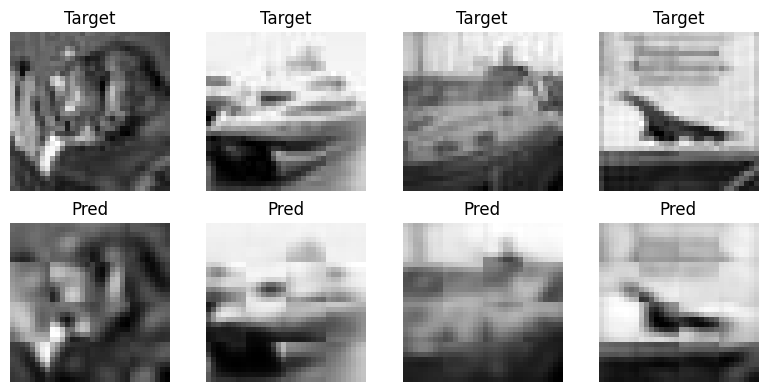

Epoch 51 val: 100%|██████████| 8/8 [00:00<00:00, 21.00it/s]


epoch=51 train_loss=0.0639 val_loss=0.0604 val_psnr=25.49


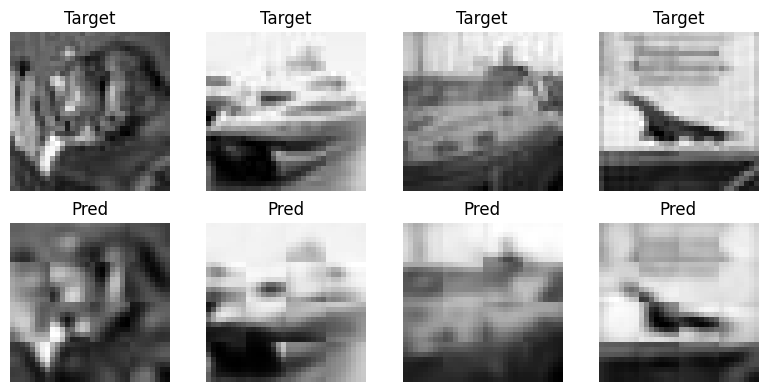

Epoch 52 val: 100%|██████████| 8/8 [00:00<00:00, 17.79it/s]


epoch=52 train_loss=0.0627 val_loss=0.0603 val_psnr=25.56


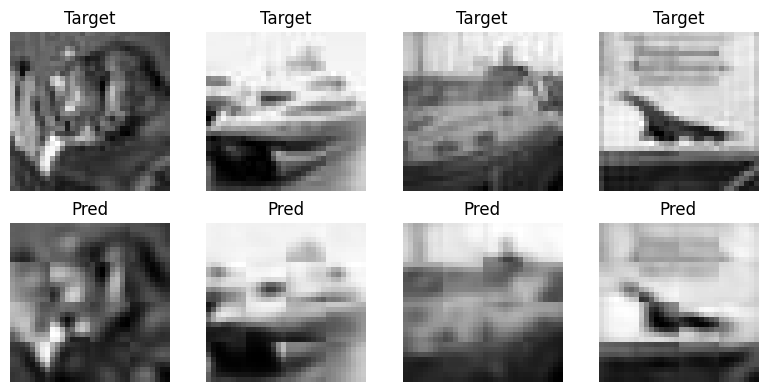

Epoch 53 val: 100%|██████████| 8/8 [00:00<00:00, 19.52it/s]


epoch=53 train_loss=0.0621 val_loss=0.0577 val_psnr=25.83


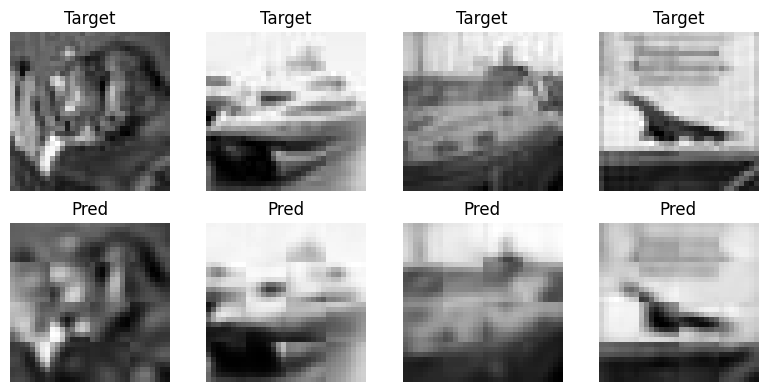

Epoch 54 val: 100%|██████████| 8/8 [00:00<00:00, 19.98it/s]


epoch=54 train_loss=0.0617 val_loss=0.0584 val_psnr=25.80


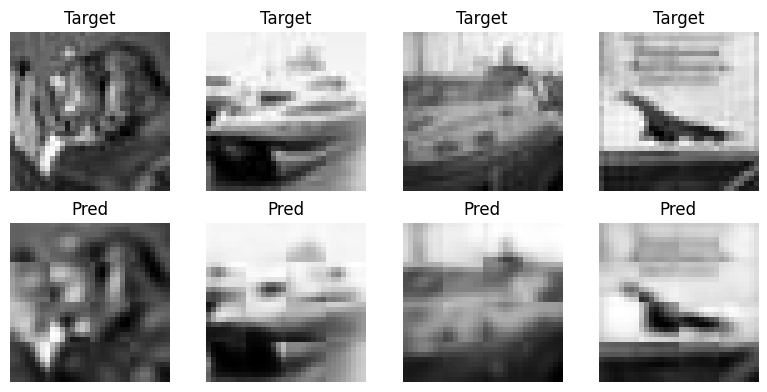

Epoch 55 val: 100%|██████████| 8/8 [00:00<00:00, 18.58it/s]


epoch=55 train_loss=0.0615 val_loss=0.0571 val_psnr=25.95


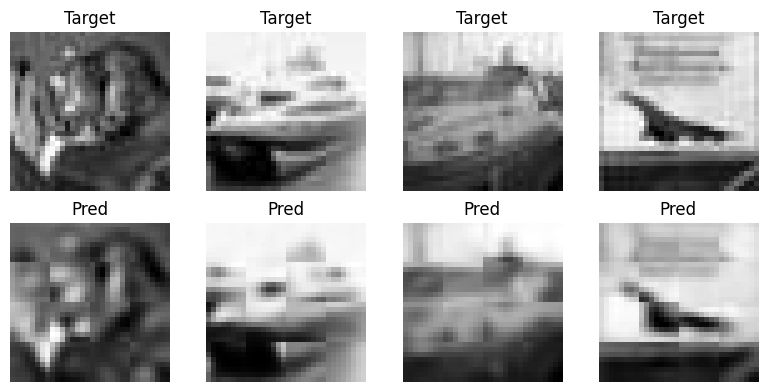

Epoch 56 val: 100%|██████████| 8/8 [00:00<00:00, 20.40it/s]


epoch=56 train_loss=0.0608 val_loss=0.0562 val_psnr=26.10


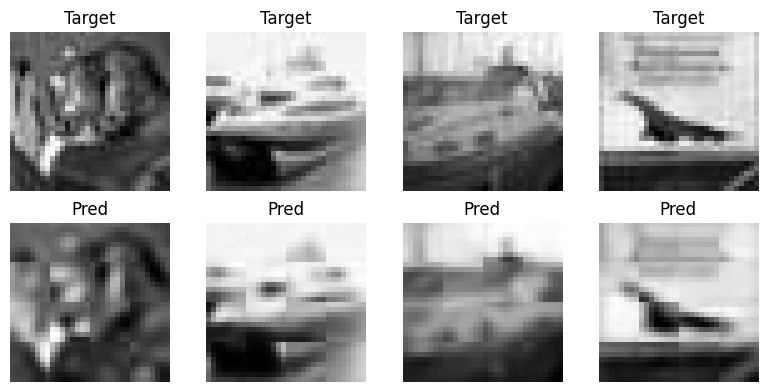

Epoch 57 val: 100%|██████████| 8/8 [00:00<00:00, 18.48it/s]


epoch=57 train_loss=0.0597 val_loss=0.0583 val_psnr=25.93


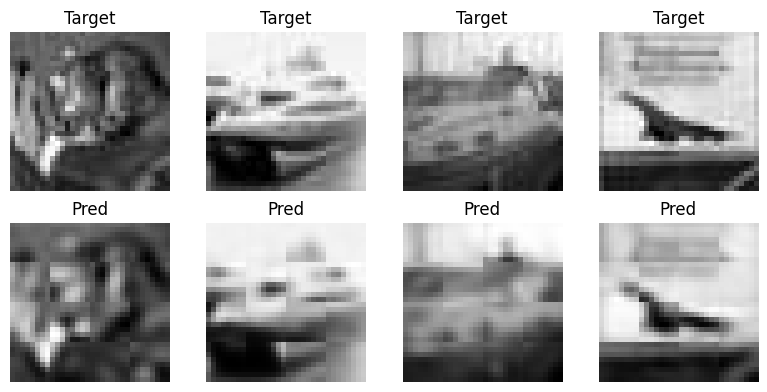

Epoch 58 val: 100%|██████████| 8/8 [00:00<00:00, 20.13it/s]


epoch=58 train_loss=0.0599 val_loss=0.0551 val_psnr=26.30


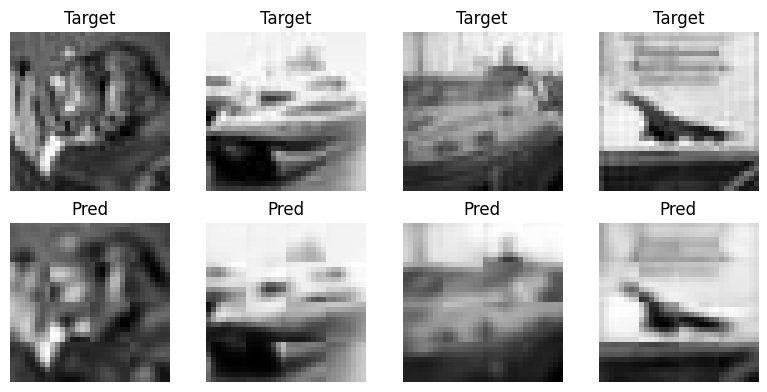

Epoch 59 val: 100%|██████████| 8/8 [00:00<00:00, 20.51it/s]


epoch=59 train_loss=0.0590 val_loss=0.0572 val_psnr=26.06


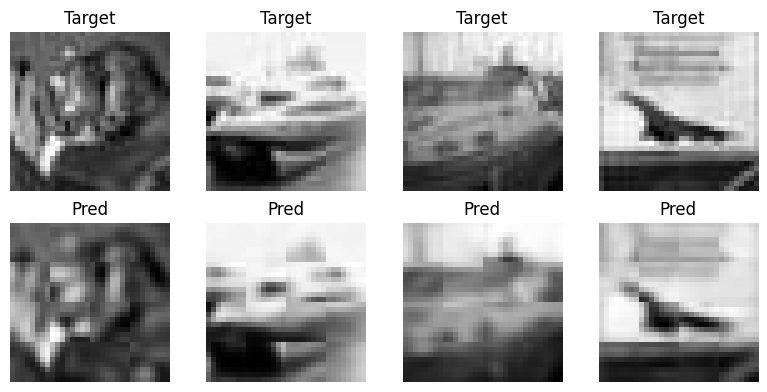

Epoch 60 val: 100%|██████████| 8/8 [00:00<00:00, 20.43it/s]


epoch=60 train_loss=0.0585 val_loss=0.0539 val_psnr=26.53


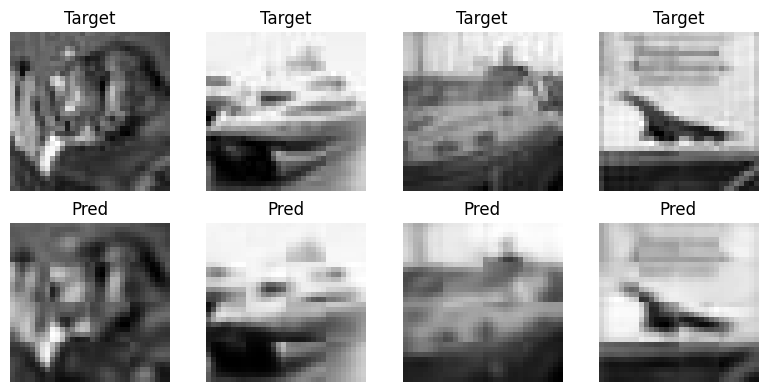

Epoch 61 val: 100%|██████████| 8/8 [00:00<00:00, 19.19it/s]


epoch=61 train_loss=0.0576 val_loss=0.0535 val_psnr=26.60


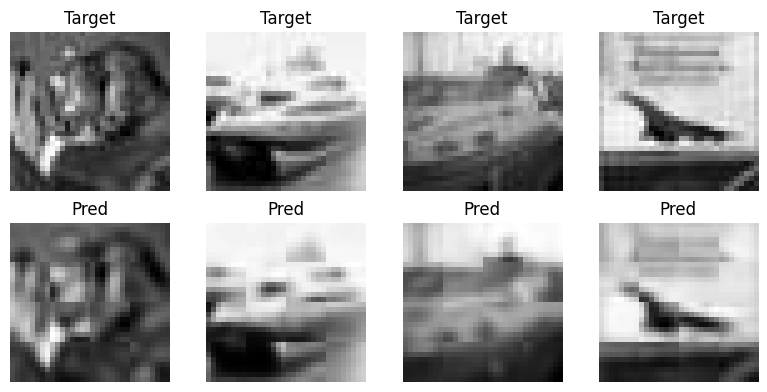

Epoch 62 val: 100%|██████████| 8/8 [00:00<00:00, 20.16it/s]


epoch=62 train_loss=0.0572 val_loss=0.0542 val_psnr=26.54


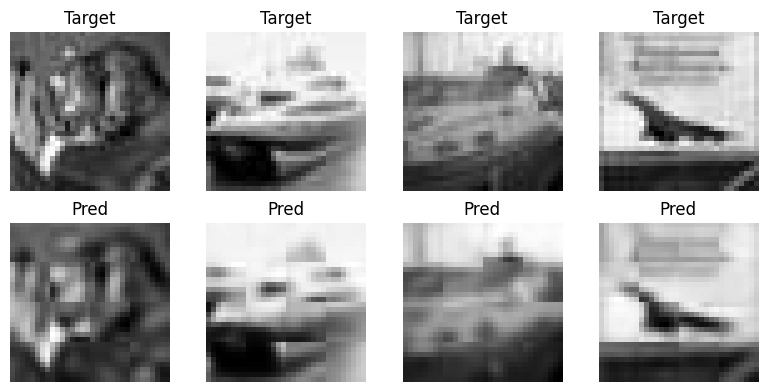

Epoch 63 val: 100%|██████████| 8/8 [00:00<00:00, 18.88it/s]


epoch=63 train_loss=0.0572 val_loss=0.0532 val_psnr=26.67


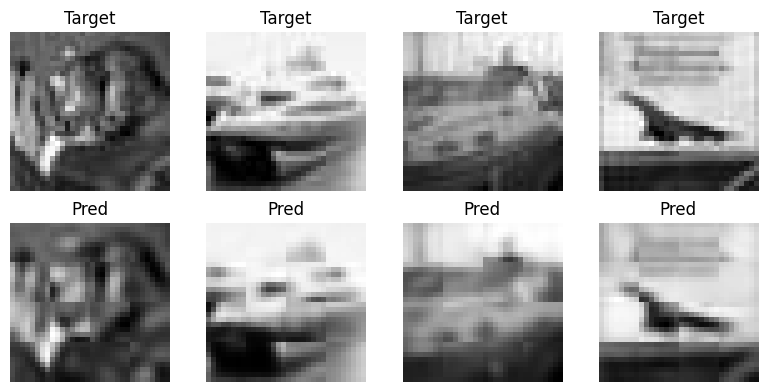

Epoch 64 val: 100%|██████████| 8/8 [00:00<00:00, 19.58it/s]


epoch=64 train_loss=0.0570 val_loss=0.0544 val_psnr=26.52


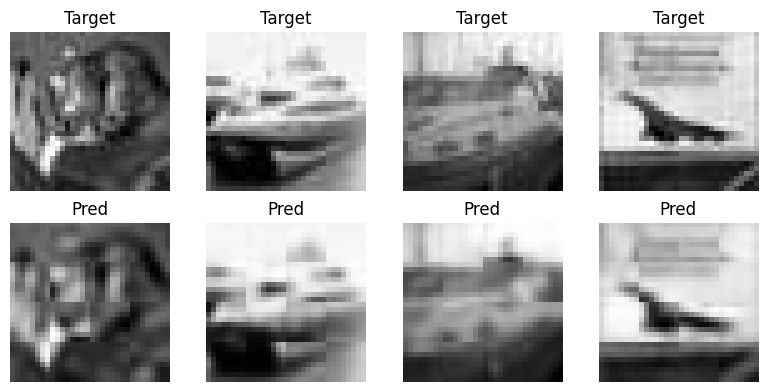

Epoch 65 val: 100%|██████████| 8/8 [00:00<00:00, 18.59it/s]


epoch=65 train_loss=0.0565 val_loss=0.0520 val_psnr=26.82


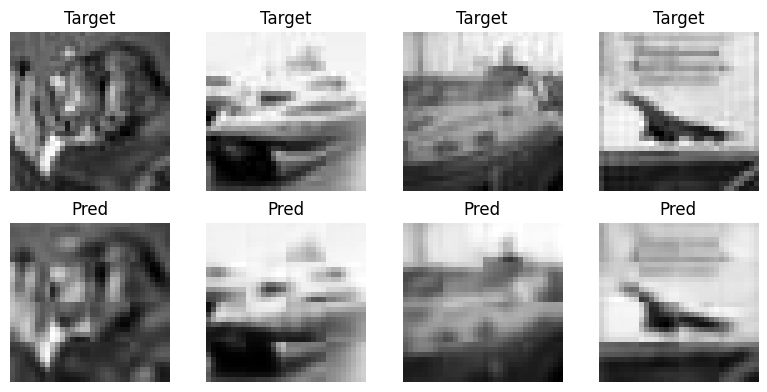

Epoch 66 val: 100%|██████████| 8/8 [00:00<00:00, 18.93it/s]


epoch=66 train_loss=0.0561 val_loss=0.0531 val_psnr=26.71


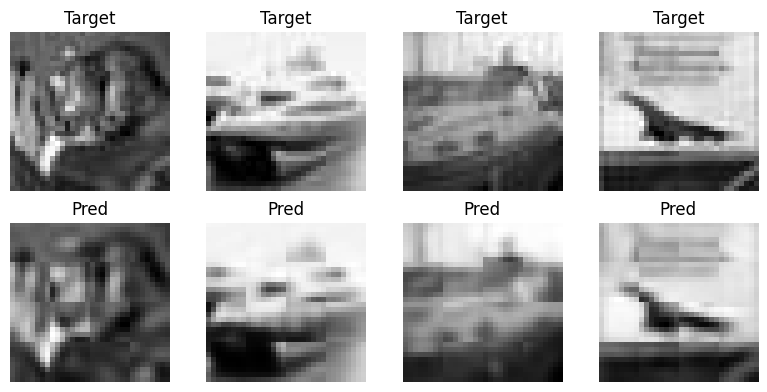

Epoch 67 val: 100%|██████████| 8/8 [00:00<00:00, 16.34it/s]


epoch=67 train_loss=0.0559 val_loss=0.0519 val_psnr=26.87


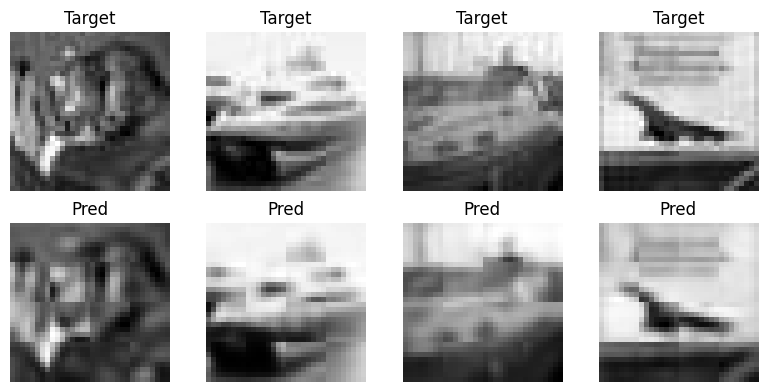

Epoch 68 val: 100%|██████████| 8/8 [00:00<00:00, 19.12it/s]


epoch=68 train_loss=0.0559 val_loss=0.0518 val_psnr=26.88


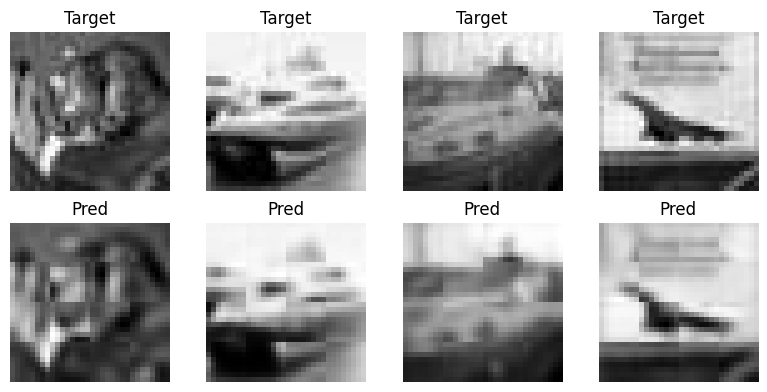

Epoch 69 val: 100%|██████████| 8/8 [00:00<00:00, 20.50it/s]


epoch=69 train_loss=0.0554 val_loss=0.0511 val_psnr=26.98


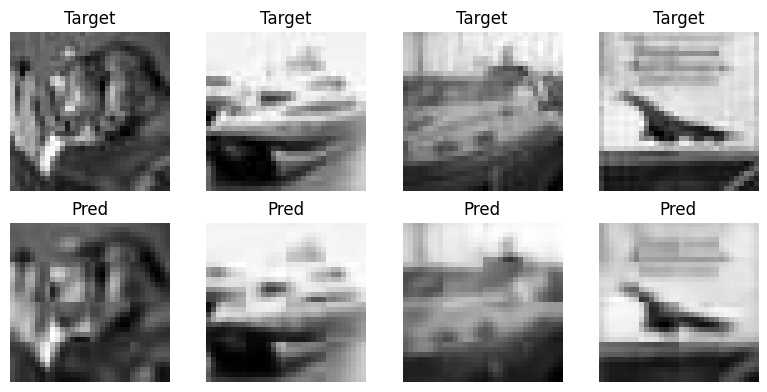

Epoch 70 val: 100%|██████████| 8/8 [00:00<00:00, 20.06it/s]


epoch=70 train_loss=0.0551 val_loss=0.0512 val_psnr=27.01


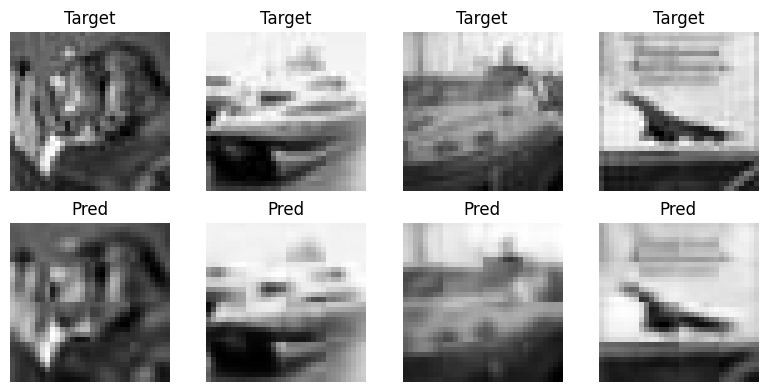

Epoch 71 val: 100%|██████████| 8/8 [00:00<00:00, 19.31it/s]


epoch=71 train_loss=0.0547 val_loss=0.0501 val_psnr=27.14


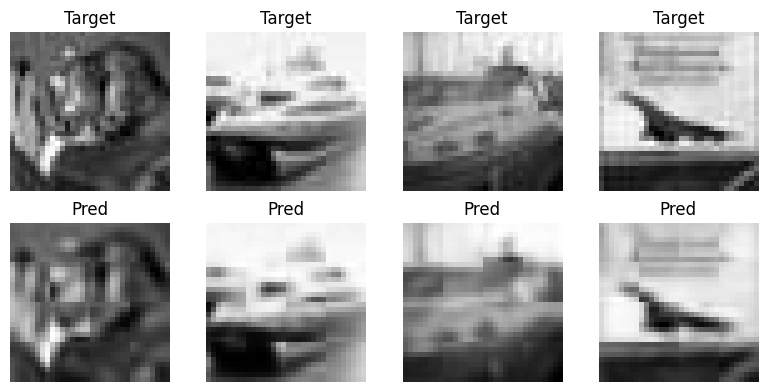

Epoch 72 val: 100%|██████████| 8/8 [00:00<00:00, 16.34it/s]


epoch=72 train_loss=0.0543 val_loss=0.0499 val_psnr=27.19


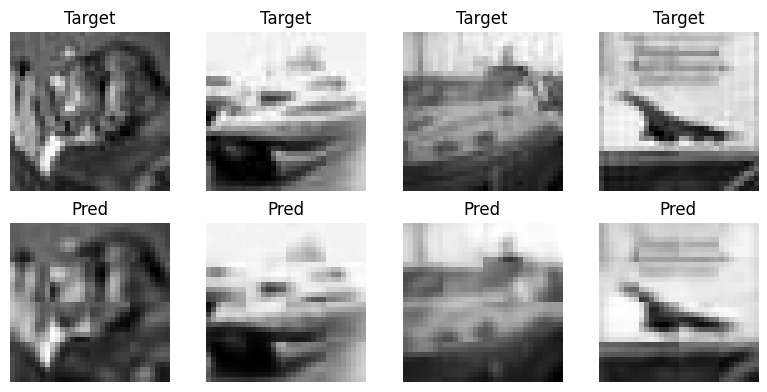

Epoch 73 val: 100%|██████████| 8/8 [00:00<00:00, 20.34it/s]


epoch=73 train_loss=0.0541 val_loss=0.0491 val_psnr=27.31


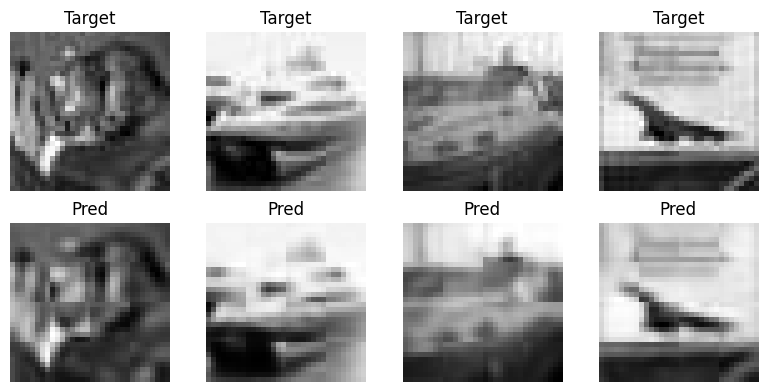

Epoch 74 val: 100%|██████████| 8/8 [00:00<00:00, 19.46it/s]


epoch=74 train_loss=0.0534 val_loss=0.0485 val_psnr=27.44


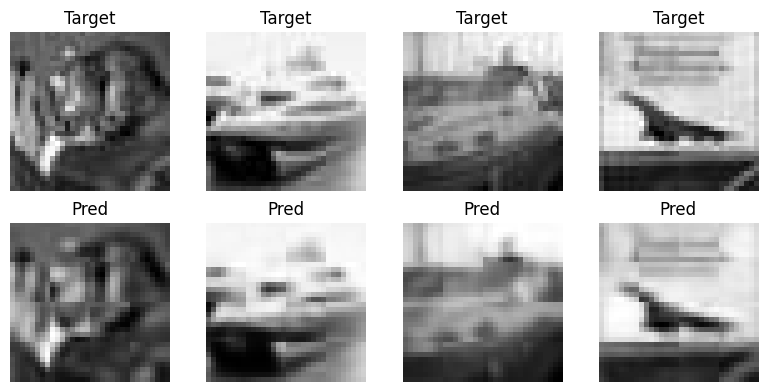

Epoch 75 val: 100%|██████████| 8/8 [00:00<00:00, 19.42it/s]


epoch=75 train_loss=0.0529 val_loss=0.0516 val_psnr=27.09


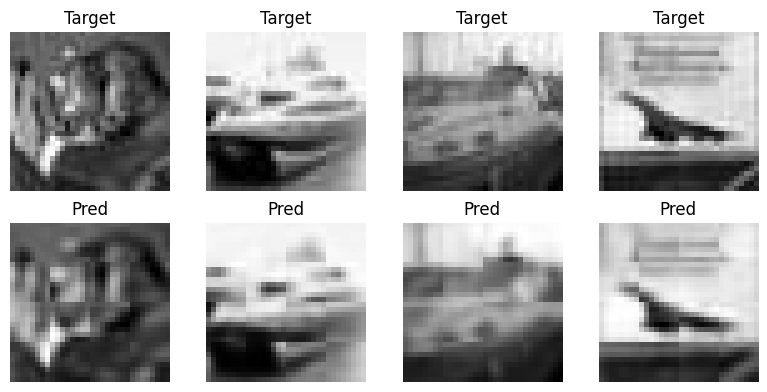

Epoch 76 val: 100%|██████████| 8/8 [00:00<00:00, 20.15it/s]


epoch=76 train_loss=0.0525 val_loss=0.0485 val_psnr=27.49


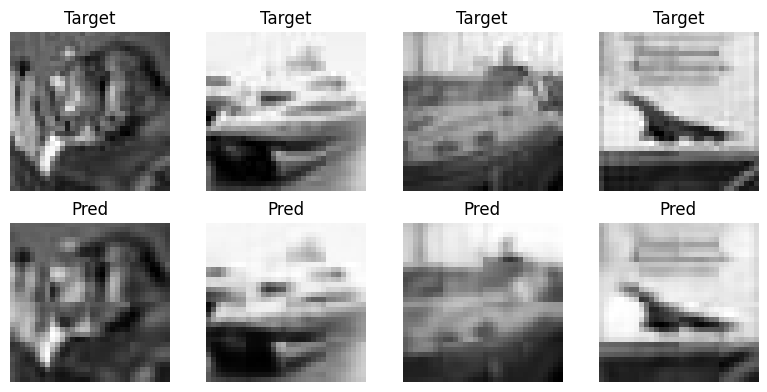

Epoch 77 val: 100%|██████████| 8/8 [00:00<00:00, 20.11it/s]


epoch=77 train_loss=0.0526 val_loss=0.0471 val_psnr=27.73


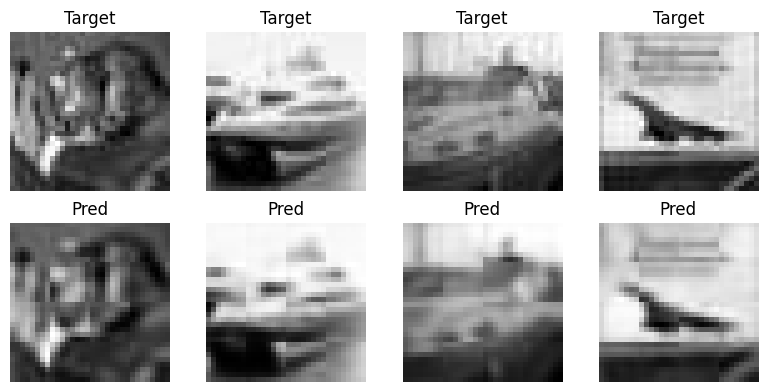

Epoch 78 val: 100%|██████████| 8/8 [00:00<00:00, 21.11it/s]


epoch=78 train_loss=0.0513 val_loss=0.0469 val_psnr=27.76


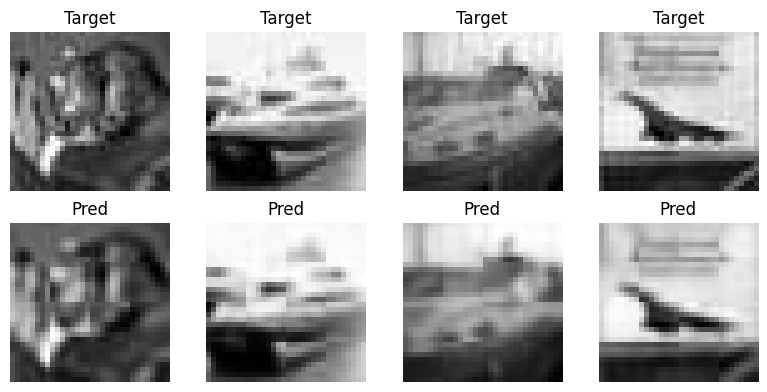

Epoch 79 val: 100%|██████████| 8/8 [00:00<00:00, 20.70it/s]


epoch=79 train_loss=0.0514 val_loss=0.0465 val_psnr=27.88


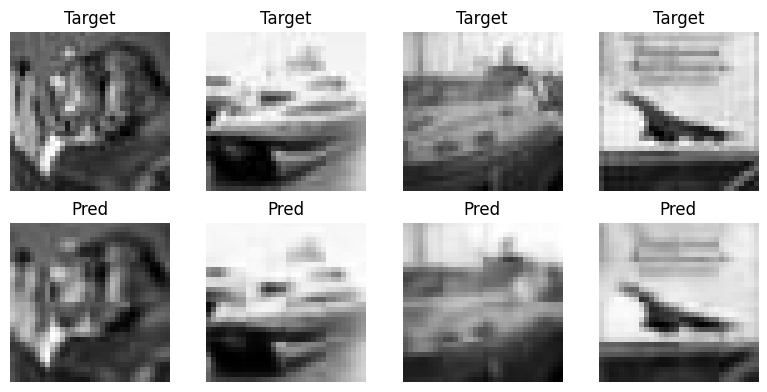

Epoch 80 val: 100%|██████████| 8/8 [00:00<00:00, 19.84it/s]


epoch=80 train_loss=0.0506 val_loss=0.0465 val_psnr=27.89


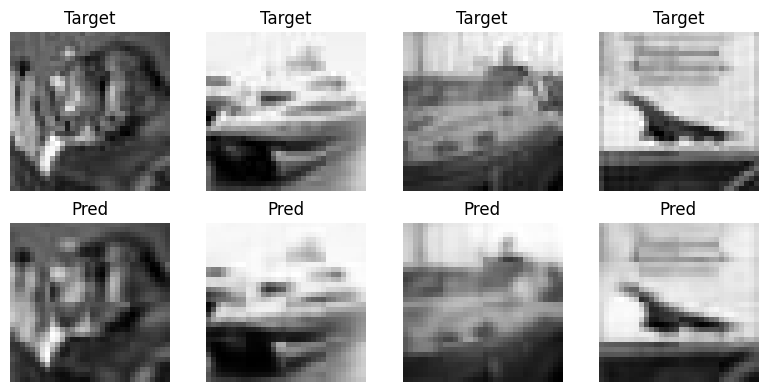

Epoch 81 val: 100%|██████████| 8/8 [00:00<00:00, 19.83it/s]


epoch=81 train_loss=0.0502 val_loss=0.0449 val_psnr=28.15


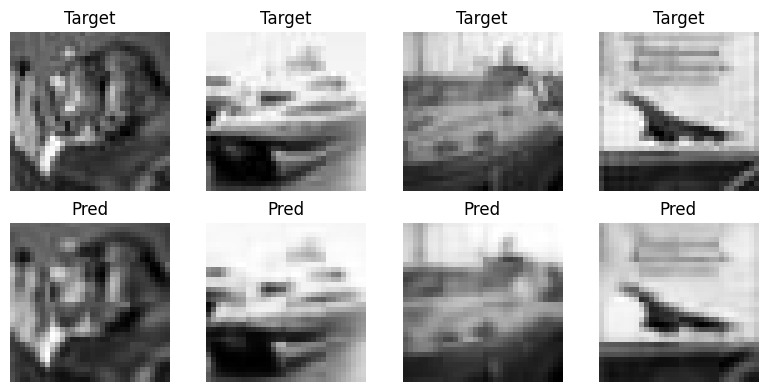

Epoch 82 val: 100%|██████████| 8/8 [00:00<00:00, 20.02it/s]


epoch=82 train_loss=0.0498 val_loss=0.0500 val_psnr=27.43


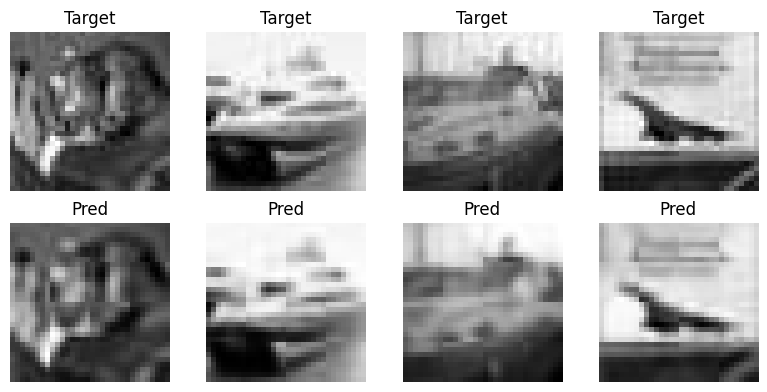

Epoch 83 val: 100%|██████████| 8/8 [00:00<00:00, 19.66it/s]


epoch=83 train_loss=0.0498 val_loss=0.0450 val_psnr=28.20


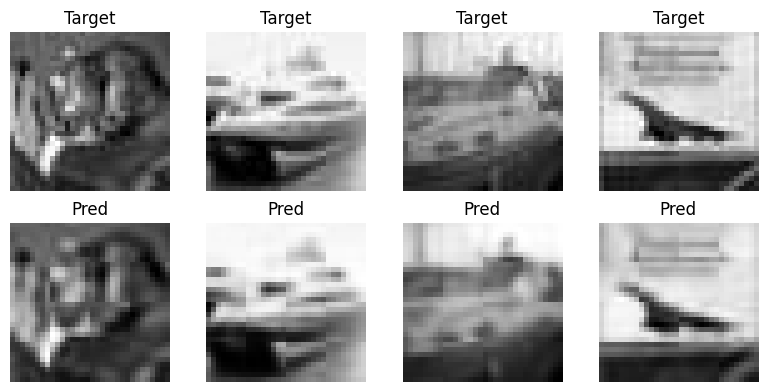

Epoch 84 val: 100%|██████████| 8/8 [00:00<00:00, 19.82it/s]


epoch=84 train_loss=0.0492 val_loss=0.0445 val_psnr=28.29


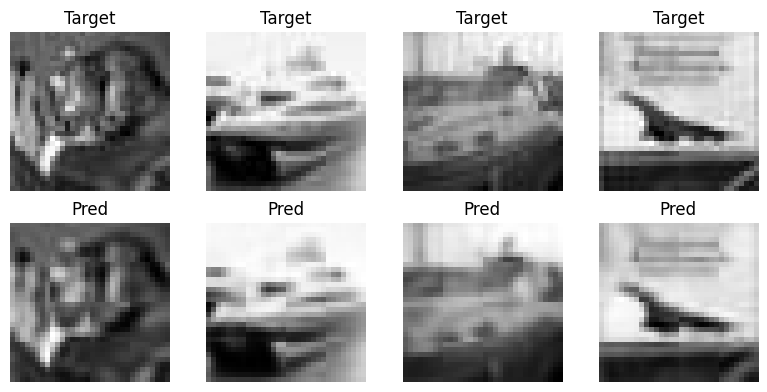

Epoch 85 val: 100%|██████████| 8/8 [00:00<00:00, 18.95it/s]


epoch=85 train_loss=0.0486 val_loss=0.0441 val_psnr=28.38


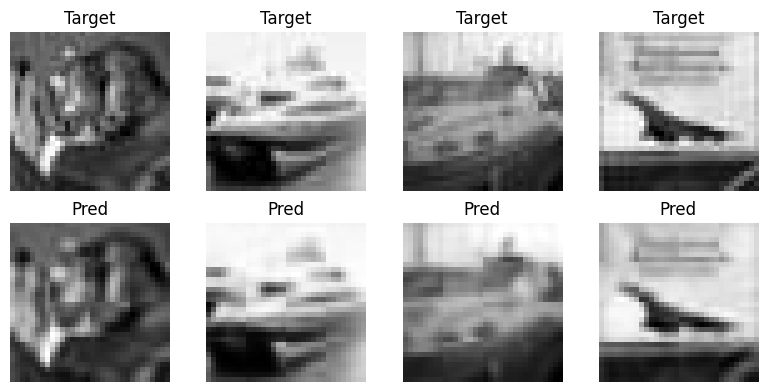

Epoch 86 val: 100%|██████████| 8/8 [00:00<00:00, 18.17it/s]


epoch=86 train_loss=0.0484 val_loss=0.0448 val_psnr=28.27


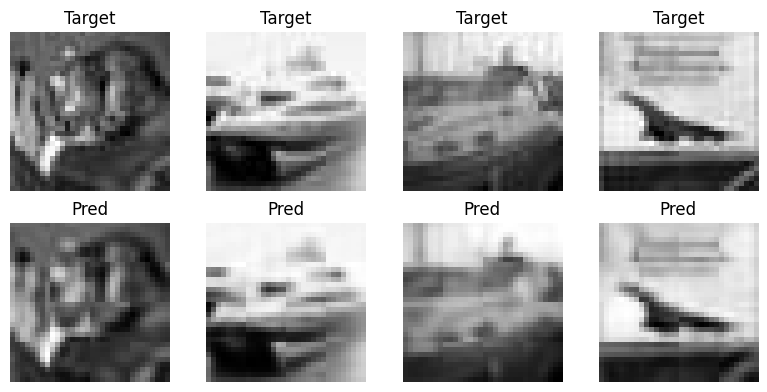

Epoch 87 val: 100%|██████████| 8/8 [00:00<00:00, 19.25it/s]


epoch=87 train_loss=0.0484 val_loss=0.0441 val_psnr=28.40


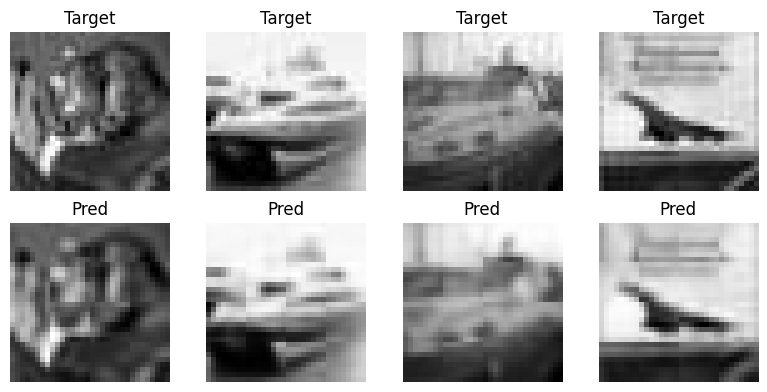

Epoch 88 val: 100%|██████████| 8/8 [00:00<00:00, 17.45it/s]


epoch=88 train_loss=0.0479 val_loss=0.0428 val_psnr=28.57


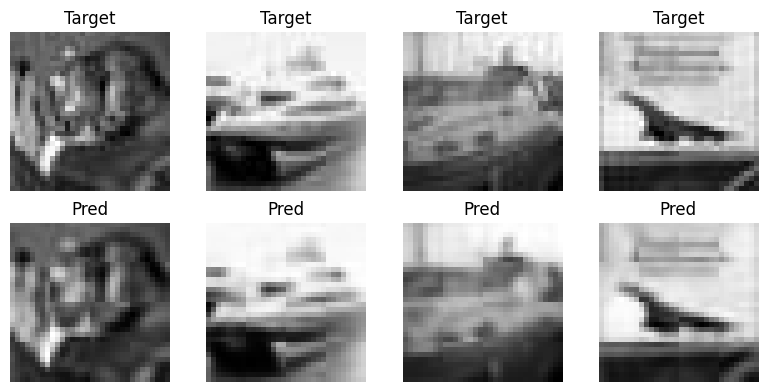

Epoch 89 val: 100%|██████████| 8/8 [00:00<00:00, 20.58it/s]


epoch=89 train_loss=0.0478 val_loss=0.0431 val_psnr=28.56


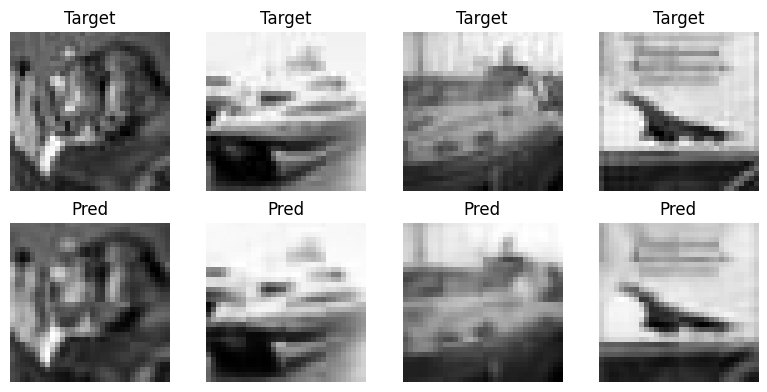

Epoch 90 val: 100%|██████████| 8/8 [00:00<00:00, 16.84it/s]


epoch=90 train_loss=0.0475 val_loss=0.0449 val_psnr=28.29


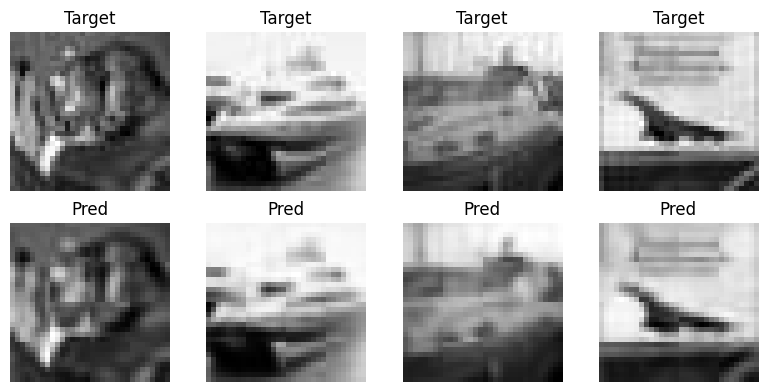

Epoch 91 val: 100%|██████████| 8/8 [00:00<00:00, 18.21it/s]


epoch=91 train_loss=0.0475 val_loss=0.0427 val_psnr=28.62


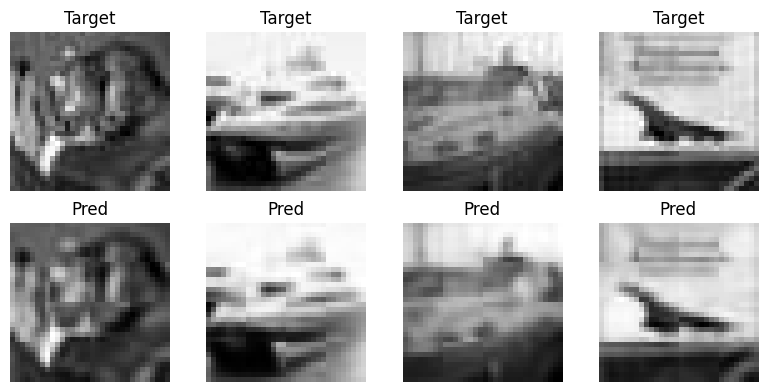

Epoch 92 val: 100%|██████████| 8/8 [00:00<00:00, 18.84it/s]


epoch=92 train_loss=0.0473 val_loss=0.0440 val_psnr=28.46


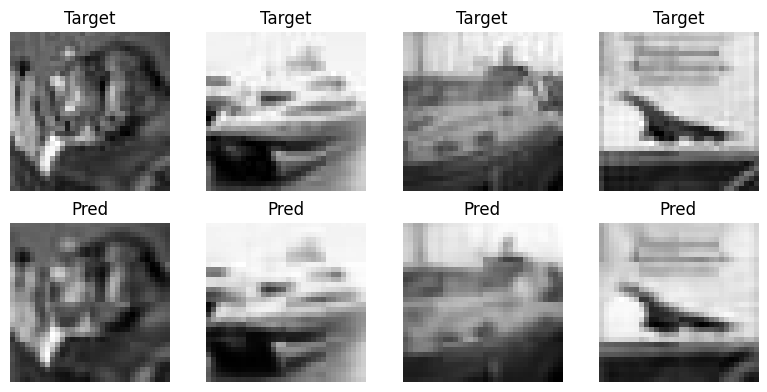

Epoch 93 val: 100%|██████████| 8/8 [00:00<00:00, 17.90it/s]


epoch=93 train_loss=0.0474 val_loss=0.0438 val_psnr=28.45


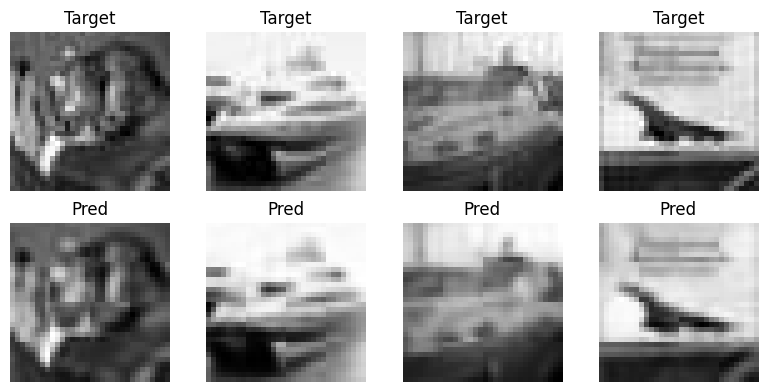

Epoch 94 val: 100%|██████████| 8/8 [00:00<00:00, 19.56it/s]


epoch=94 train_loss=0.0473 val_loss=0.0423 val_psnr=28.68


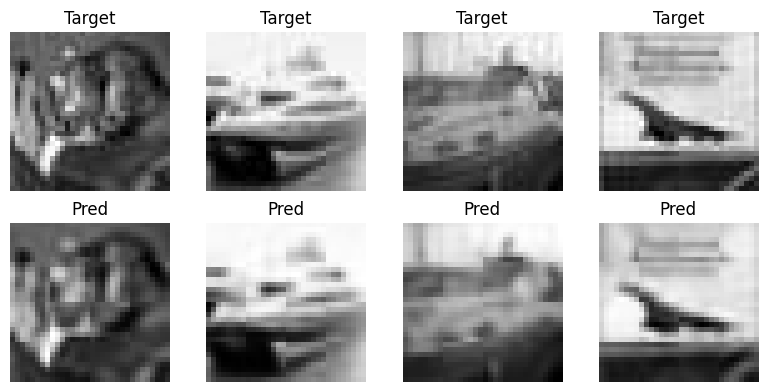

Epoch 95 val: 100%|██████████| 8/8 [00:00<00:00, 17.88it/s]


epoch=95 train_loss=0.0468 val_loss=0.0439 val_psnr=28.46


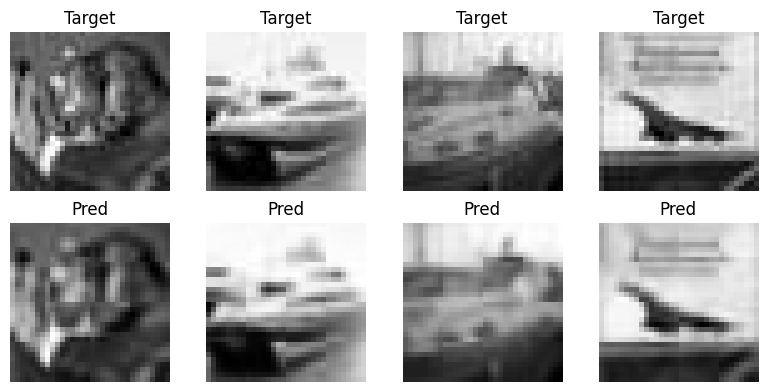

Epoch 96 val: 100%|██████████| 8/8 [00:00<00:00, 20.62it/s]


epoch=96 train_loss=0.0469 val_loss=0.0427 val_psnr=28.63


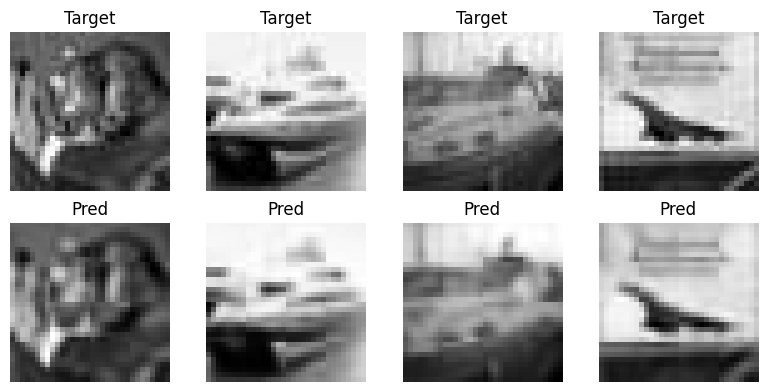

Epoch 97 val: 100%|██████████| 8/8 [00:00<00:00, 20.25it/s]


epoch=97 train_loss=0.0467 val_loss=0.0438 val_psnr=28.47


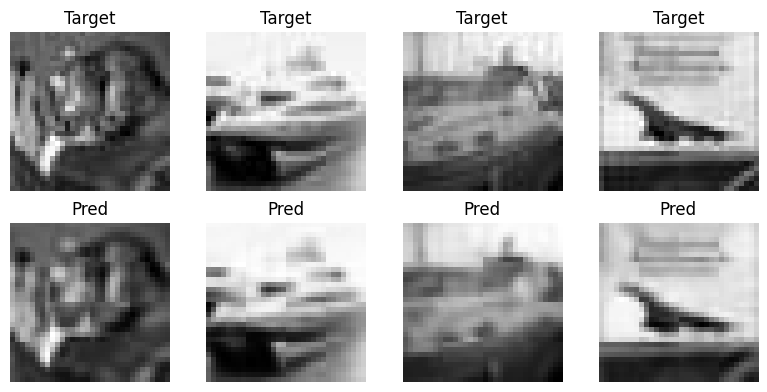

Epoch 98 val: 100%|██████████| 8/8 [00:00<00:00, 20.31it/s]


epoch=98 train_loss=0.0467 val_loss=0.0422 val_psnr=28.73


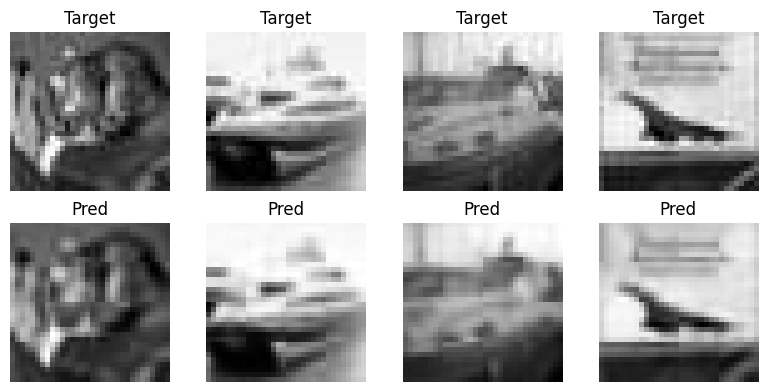

Epoch 99 val: 100%|██████████| 8/8 [00:00<00:00, 19.44it/s]


epoch=99 train_loss=0.0466 val_loss=0.0423 val_psnr=28.68


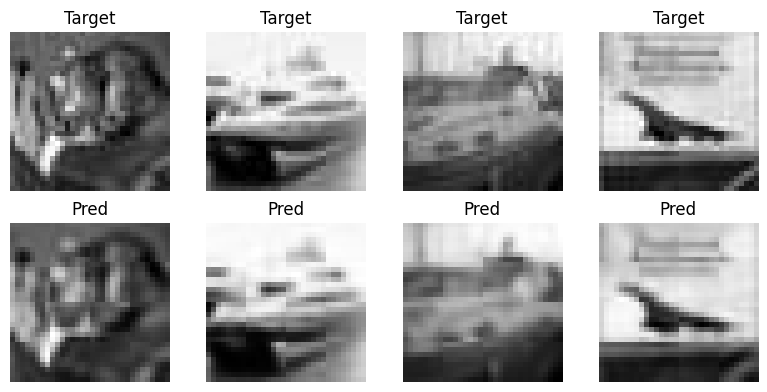

Epoch 100 val: 100%|██████████| 8/8 [00:00<00:00, 20.61it/s]


epoch=100 train_loss=0.0470 val_loss=0.0424 val_psnr=28.71


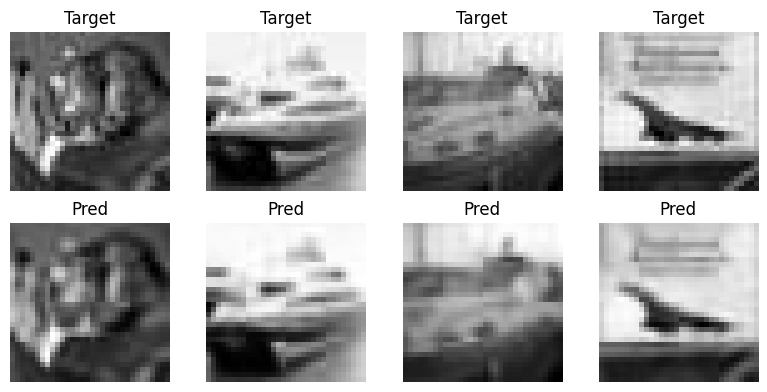

In [39]:
# continue N more epochs:
config["epochs"] = 35
n_more_epochs = 65

config["output_dir"].mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_psnr": []}

for epoch in range(config["epochs"] + 1, config["epochs"] + n_more_epochs + 1):
    model.train()
    train_loss = 0.0

    for coefficients, qtable, target in tqdm(train_loader, desc=f"Epoch {epoch} train"):
        coefficients = coefficients.to(device)
        qtable = qtable.to(device)
        target = target.to(device)

        pred = model(coefficients, qtable)
        loss = reconstruction_loss(pred, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_psnr = 0.0
    preview_batch = None

    with torch.no_grad():
        for coefficients, qtable, target in tqdm(val_loader, desc=f"Epoch {epoch} val"):
            coefficients = coefficients.to(device)
            qtable = qtable.to(device)
            target = target.to(device)

            pred = model(coefficients, qtable)
            val_loss += reconstruction_loss(pred, target).item()
            val_psnr += psnr(pred, target).item()

            if preview_batch is None:
                preview_batch = (pred.cpu(), target.cpu())

    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)

    checkpoint = {
        "model": model.state_dict(),
        "config": config,
        "epoch": epoch,
        "val_loss": val_loss,
        "val_psnr": val_psnr,
    }

    torch.save(checkpoint, config["output_dir"] / "last.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, config["output_dir"] / "best.pt")

    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_psnr={val_psnr:.2f}"
    )

    pred_preview, target_preview = preview_batch

    plt.figure(figsize=(8, 4))
    for i in range(min(4, pred_preview.size(0))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(target_preview[i].squeeze(0), cmap="gray")
        plt.axis("off")
        plt.title("Target")

        plt.subplot(2, 4, i + 5)
        plt.imshow(pred_preview[i].clamp(0, 1).squeeze(0), cmap="gray")
        plt.axis("off")
        plt.title("Pred")

    plt.tight_layout()
    plt.show()

Model inference time: 0.0479 seconds
Mean Squared Error: 0.0019


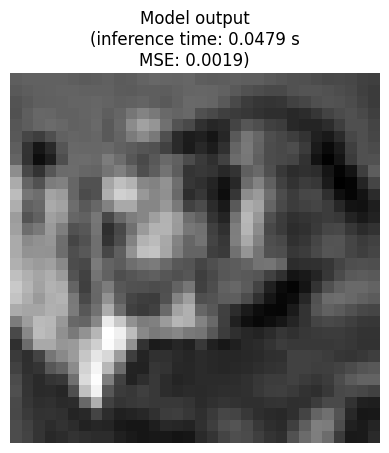

In [46]:
# check one sample inference time and compare it to regular jpeg decoding time:
import time
coefficients, qtable, target = val_dataset[0]
coefficients = coefficients.unsqueeze(0).to(device)
qtable = qtable.unsqueeze(0).to(device)
start_time = time.time()
with torch.no_grad():
    pred = model(coefficients, qtable)
inference_time = time.time() - start_time
print(f"Model inference time: {inference_time:.4f} seconds")
pred_image = pred.squeeze(0).cpu().numpy()
real_image = target.squeeze(0).cpu().numpy()
mse = ((pred_image - real_image) ** 2).mean()
print(f"Mean Squared Error: {mse:.4f}")
#plt.imshow(pred_image, cmap="gray")
#TypeError: Invalid shape (1, 32, 32) for image data
plt.imshow(pred_image.squeeze(0), cmap="gray")
plt.axis("off")
plt.title(f"Model output\n(inference time: {inference_time:.4f} s\nMSE: {mse:.4f})")
plt.show()